In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Set global plot settings
plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 16


In [24]:
df = pd.read_excel("/content/1_Vehicle Population Statistics (1).xlsx")

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sr No.                        900 non-null    float64
 1   Year                          900 non-null    object 
 2   Region                        900 non-null    object 
 3   Category                      900 non-null    object 
 4   Motor Cycles                  901 non-null    object 
 5   Scooters                      901 non-null    object 
 6   Moped                         901 non-null    object 
 7   Cars                          901 non-null    object 
 8   Jeeps                         901 non-null    object 
 9   Stn. Wagons                   901 non-null    object 
 10  Taxis meter fited             901 non-null    object 
 11  Luxury /Tourist Cabs          901 non-null    object 
 12  Auto-rickshaws                901 non-null    object 
 13  Stage

In [26]:
columns_to_convert = ['Motor Cycles','Scooters','Moped','Cars','Jeeps','Stn. Wagons','Taxis meter fited','Luxury /Tourist Cabs','Auto-rickshaws','Stage carriages','Contract carriages /Mini Bus','School Buses','Private Service Vehicles','Ambulances','Articulated/Multi.','Trucks & Lorries','Tanker','Delivery Van (4 wheelers)','Delivery Van (3 wheelers)','Tractors','Trailors']
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')


The code begins with a list of column names (columns_to_convert) that need to be converted into numeric format.
It then loops through each column in the list, applying the pd.to_numeric() function to convert its values.
Key Detail: The errors='coerce' parameter ensures that any non-numeric value (like 'N/A' or 'Unknown') is safely replaced with NaN, preventing errors.

In [27]:
# Data Cleaning
df.drop('Sr No.', axis=1, inplace=True)
df.columns = df.columns.str.strip()
df.fillna(0, inplace=True)
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns


df.columns = df.columns.str.strip()
This removes any leading or trailing spaces from column names.

df.fillna(0, inplace=True)
This replaces all missing values (NaN) in the dataset with 0.

This dynamically selects all columns with numeric data types (float64 or int64), filtering out non-numeric or object-type columns.

In [28]:
df[numerical_columns]

,Motor Cycles,Scooters,Moped,Cars,Jeeps,Stn. Wagons,Taxis meter fited,Luxury /Tourist Cabs,Auto-rickshaws,Stage carriages,...,Articulated/Multi.,Trucks & Lorries,Tanker,Delivery Van (4 wheelers),Delivery Van (3 wheelers),Tractors,Trailors,Others,Private Vehicles TOTAL,Commercial vehicles TOTAL
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,84289.0,62444.0,7289.0,164758.0,12727.0,2705.0,40451.0,0.0,0.0,5394.0,...,0.0,9022.0,1214.0,9329.0,4079.0,867.0,866.0,3761.0,334212.0,74898.0
2,80320.0,96297.0,15230.0,110397.0,5465.0,962.0,11460.0,0.0,60128.0,0.0,...,0.0,5637.0,117.0,5019.0,9517.0,370.0,127.0,445.0,308671.0,97725.0
3,39930.0,44932.0,9786.0,42945.0,4439.0,472.0,10536.0,0.0,41786.0,0.0,...,0.0,3811.0,697.0,4180.0,4004.0,124.0,170.0,577.0,142504.0,66770.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896,292925.0,83106.0,32112.0,29634.0,14171.0,33.0,33.0,1938.0,5129.0,2625.0,...,1502.0,12391.0,217.0,12095.0,2409.0,13044.0,3580.0,1437.0,451981.0,57716.0
897,92015.0,22833.0,1974.0,5212.0,3036.0,1.0,1.0,442.0,594.0,4.0,...,4.0,512.0,29.0,2088.0,157.0,7559.0,3743.0,133.0,125071.0,15480.0
898,272891.0,96182.0,58270.0,30185.0,7630.0,63.0,136.0,1096.0,7735.0,358.0,...,1497.0,9866.0,280.0,8377.0,2505.0,13576.0,7034.0,1016.0,465221.0,53741.0
899,167075.0,35236.0,19699.0,10472.0,4357.0,6.0,0.0,368.0,957.0,11.0,...,4.0,1887.0,139.0,3241.0,463.0,8999.0,5212.0,256.0,236845.0,21945.0


In [29]:
df[numerical_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901 entries, 0 to 900
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Motor Cycles                  901 non-null    float64
 1   Scooters                      901 non-null    float64
 2   Moped                         901 non-null    float64
 3   Cars                          901 non-null    float64
 4   Jeeps                         901 non-null    float64
 5   Stn. Wagons                   901 non-null    float64
 6   Taxis meter fited             901 non-null    float64
 7   Luxury /Tourist Cabs          901 non-null    float64
 8   Auto-rickshaws                901 non-null    float64
 9   Stage carriages               901 non-null    float64
 10  Contract carriages /Mini Bus  901 non-null    float64
 11  School Buses                  901 non-null    float64
 12  Private Service Vehicles      901 non-null    float64
 13  Ambul

In [54]:
 '''Step 2: Analyze Vehicle Population Trends'''

region_trends = df.groupby('Region').sum()[['Private Vehicles TOTAL', 'Commercial vehicles TOTAL']]


In [31]:
region_trends = region_trends.iloc[1:]
print(region_trends)

                   Private Vehicles TOTAL  Commercial vehicles TOTAL
Region                                                              
Amrawati Region                16900116.0                  2919485.0
Aurangabad Region              14028969.0                  2708417.0
Dhule Region                   11328771.0                  2580556.0
Greater Mumbai                 29185595.0                  4648178.0
Kolhapur Region                25291981.0                  4037988.0
Latur Region                    5207236.0                  1278664.0
Nagpur(R) Region               11855571.0                  1544932.0
Nagpur(U) Region               20209927.0                  1512623.0
Nanded Region                   6379397.0                  1415128.0
Nashik Region                  26932434.0                  4850377.0
Panvel Region                   9924998.0                  2413325.0
Pune Region                    56301631.0                  6566631.0
Thane Region                   275

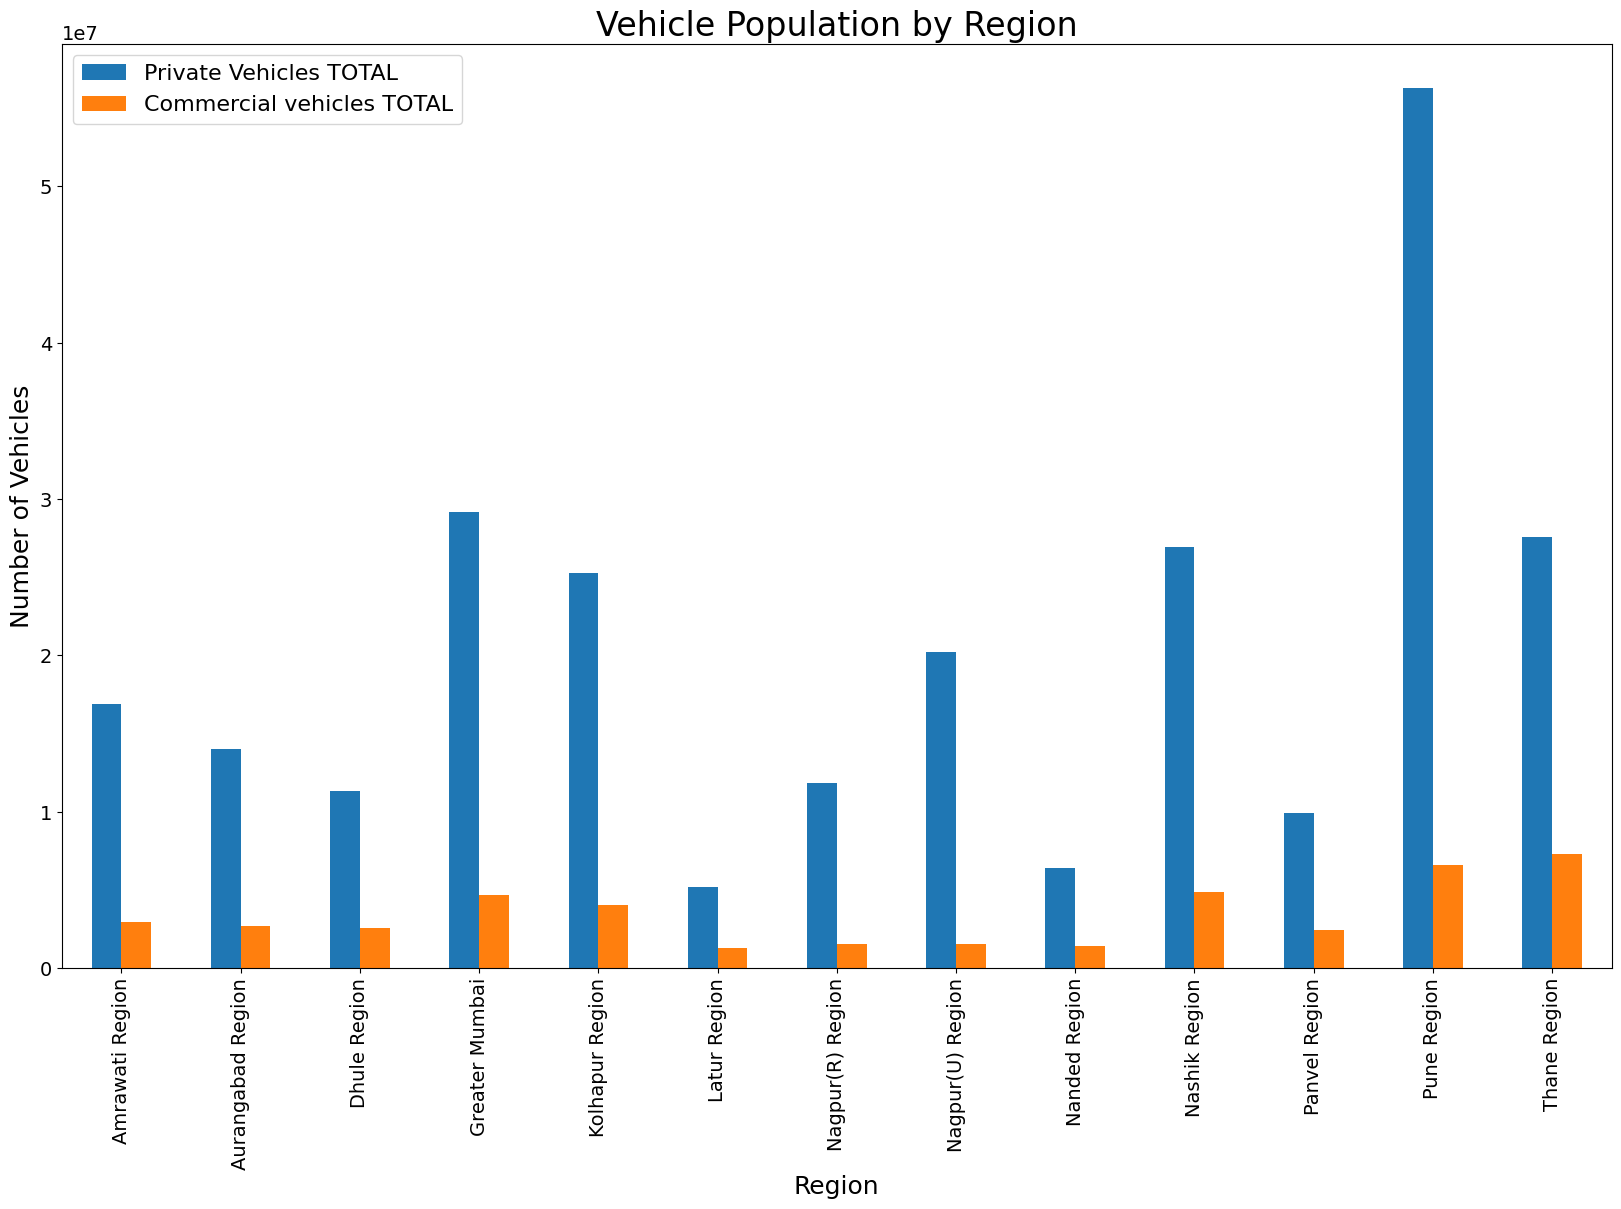

In [32]:
# Plot trends for each region
region_trends.plot(kind='bar', figsize=(20, 12))
plt.title('Vehicle Population by Region')
plt.ylabel('Number of Vehicles')
plt.xlabel('Region')
plt.show()

In [33]:
df['Year'].unique()

array([0, '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005',
       '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010',
       '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015',
       '2015-2016', '2016-2017', '2017-2018'], dtype=object)

In [55]:
# Plot growth trend over time for private vs commercial vehicles
df['Year'] = df['Year'].astype(str)  # Ensure Year is treated as categorical for grouping

In [56]:
time_trends = df.groupby('Year').sum()[['Private Vehicles TOTAL', 'Commercial vehicles TOTAL']]
print(time_trends)

           Private Vehicles TOTAL  Commercial vehicles TOTAL
Year                                                        
0                             0.0                        0.0
2000-2001               5441279.0                  1308137.0
2001-2002               6123444.0                  1379928.0
2002-2003               6675547.0                  1447612.0
2003-2004               7416150.0                  1541366.0
2004-2005               8262005.0                  1661516.0
2005-2006               9171733.0                  1779744.0
2006-2007               9348794.0                  1923052.0
2007-2008              11179315.0                  2075106.0
2008-2009              12191531.0                  2235277.0
2009-2010              13364731.0                  2376624.0
2010-2011              14869415.0                  2537496.0
2011-2012              16671930.0                  2727874.0
2012-2013              18522532.0                  2929886.0
2013-2014              2

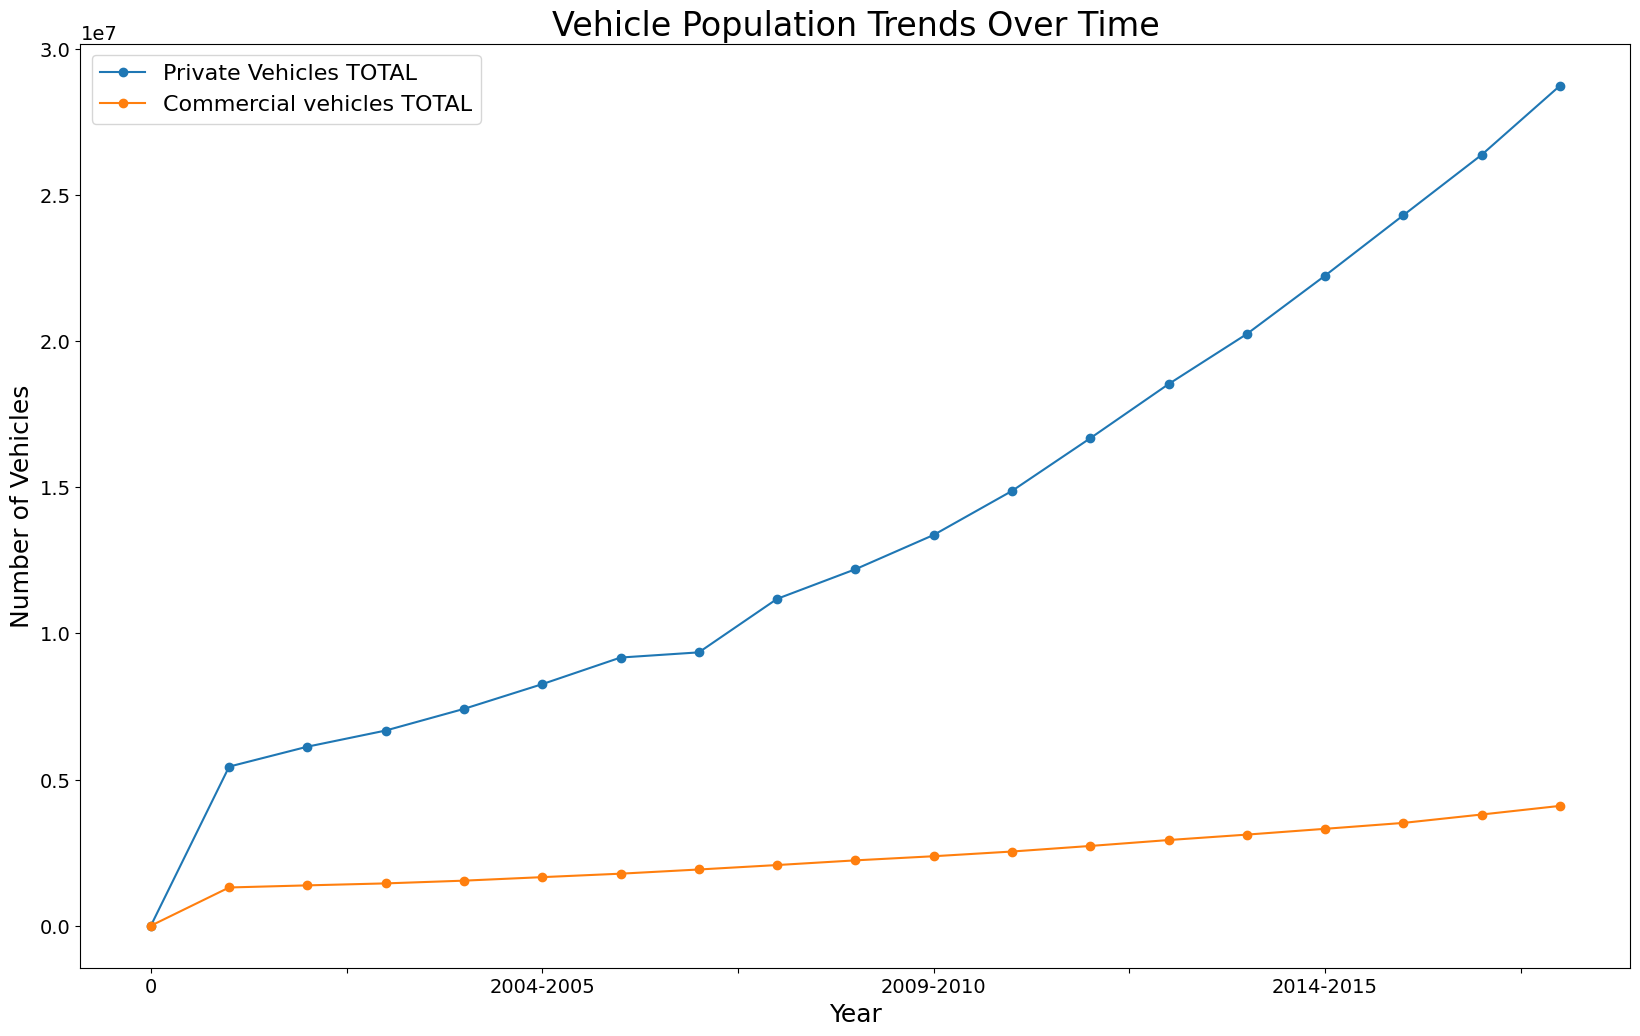

In [57]:
time_trends.plot(kind='line', figsize=(20, 12), marker='o')
plt.title('Vehicle Population Trends Over Time')
plt.ylabel('Number of Vehicles')
plt.xlabel('Year')
plt.show()

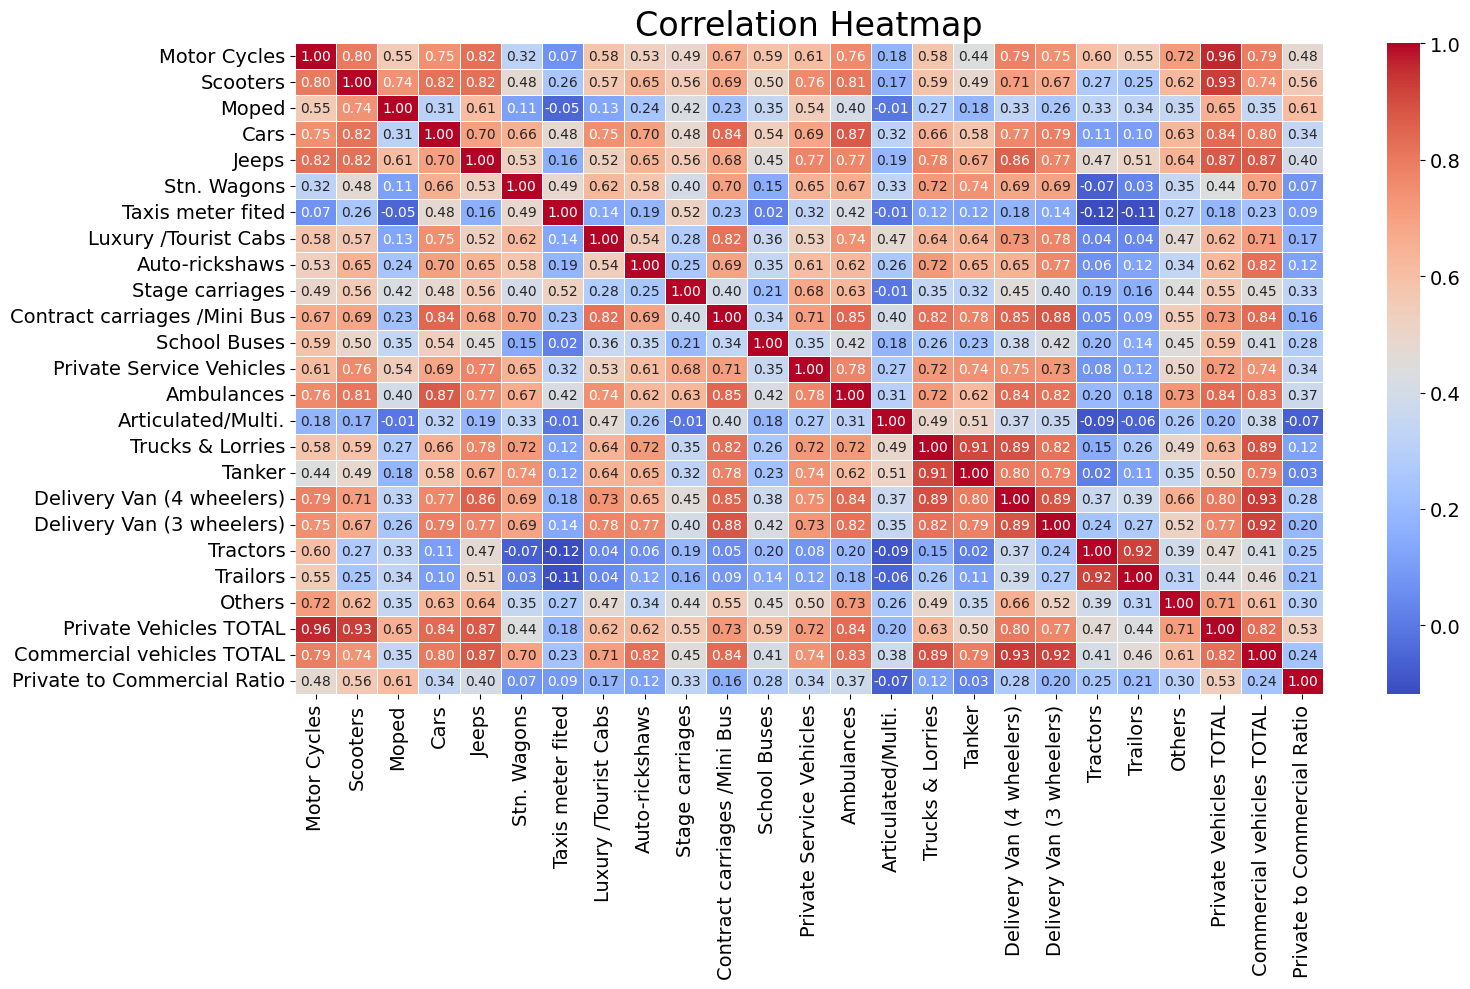

In [59]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
'''This ensures that the correlation matrix is calculated only for valid numerical data, avoiding errors from non-numeric columns.'''

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



Regions with the Highest Private Vehicle Demand:
Region
Pune Region        56301631.0
Greater Mumbai     29185595.0
Thane Region       27553063.0
Nashik Region      26932434.0
Kolhapur Region    25291981.0
Name: Private Vehicles TOTAL, dtype: float64


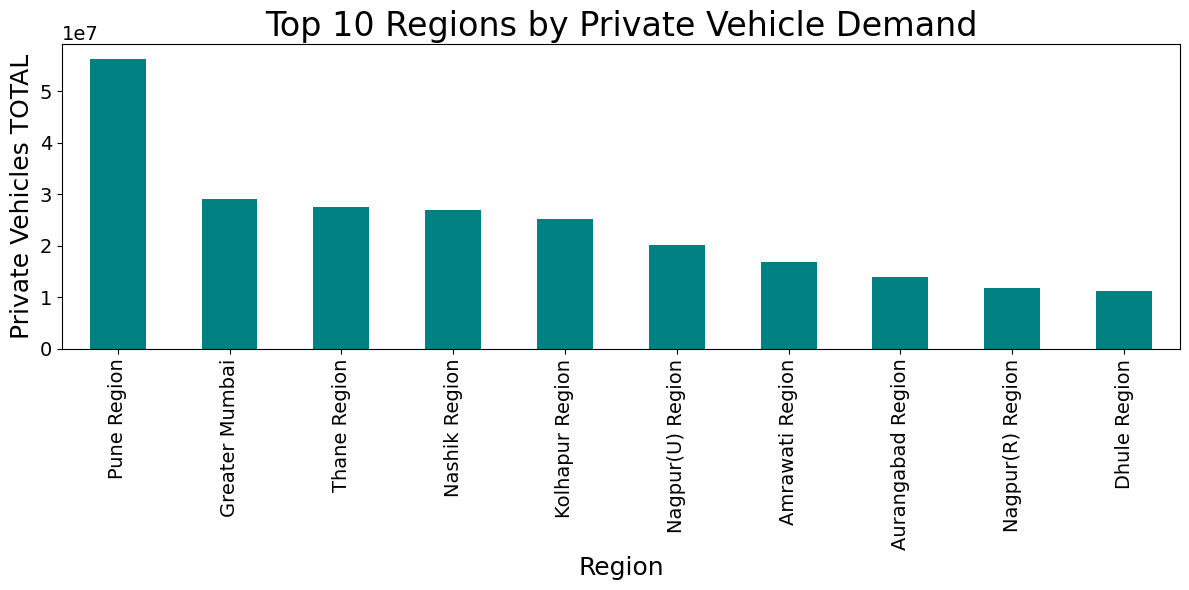

In [60]:
# Group by region and sum private vehicles
region_demand = df.groupby('Region').sum()['Private Vehicles TOTAL'].sort_values(ascending=False)

print("Regions with the Highest Private Vehicle Demand:")
print(region_demand.head(5))

# Visualize the top regions
plt.figure(figsize=(12, 6))
region_demand.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Regions by Private Vehicle Demand')
plt.ylabel('Private Vehicles TOTAL')
plt.xlabel('Region')
plt.tight_layout()
plt.show()


In [50]:
# Assuming the correct column name is 'Private Vehicles TOTAL' and 'Commercial vehicles TOTAL',
# calculate the growth rate and create new columns
region_trends['Private Growth Rate (%)'] = (region_trends['Private Vehicles TOTAL'] / region_trends['Private Vehicles TOTAL'].shift(1) - 1) * 100
region_trends['Commercial Growth Rate (%)'] = (region_trends['Commercial vehicles TOTAL'] / region_trends['Commercial vehicles TOTAL'].shift(1) - 1) * 100

# Highlight top 5 regions for private and commercial vehicle growth
top_private_growth = region_trends.sort_values('Private Growth Rate (%)', ascending=False).head(5)
top_commercial_growth = region_trends.sort_values('Commercial Growth Rate (%)', ascending=False).head(5)

print("\nTop 5 Regions with Highest Private Vehicle Growth:")
print(top_private_growth[['Private Growth Rate (%)']])

print("\nTop 5 Regions with Highest Commercial Vehicle Growth:")
print(top_commercial_growth[['Commercial Growth Rate (%)']])


Top 5 Regions with Highest Private Vehicle Growth:
                   Private Growth Rate (%)
Region                                    
Aurangabad Region                      inf
Pune Region                     467.270956
Nashik Region                   322.178366
Greater Mumbai                  157.623665
Nagpur(R) Region                127.674932

Top 5 Regions with Highest Commercial Vehicle Growth:
                   Commercial Growth Rate (%)
Region                                       
Aurangabad Region                         inf
Nashik Region                      242.751822
Pune Region                        172.098909
Greater Mumbai                      80.123121
Nagpur(R) Region                    20.823922



Top 5 Regions with Highest Private Vehicle Growth:
                  Private Growth Rate (%)  Private Vehicles TOTAL
Region                                                           
Pune Region                    467.270956              56301631.0
Nashik Region                  322.178366              26932434.0
Greater Mumbai                 157.623665              29185595.0
Nagpur(R) Region               127.674932              11855571.0
Nagpur(U) Region                70.467766              20209927.0

Top 5 Regions with Highest Commercial Vehicle Growth:
                  Commercial Growth Rate (%)  Commercial vehicles TOTAL
Region                                                                 
Nashik Region                     242.751822                  4850377.0
Pune Region                       172.098909                  6566631.0
Greater Mumbai                     80.123121                  4648178.0
Nagpur(R) Region                   20.823922                  1544932.0

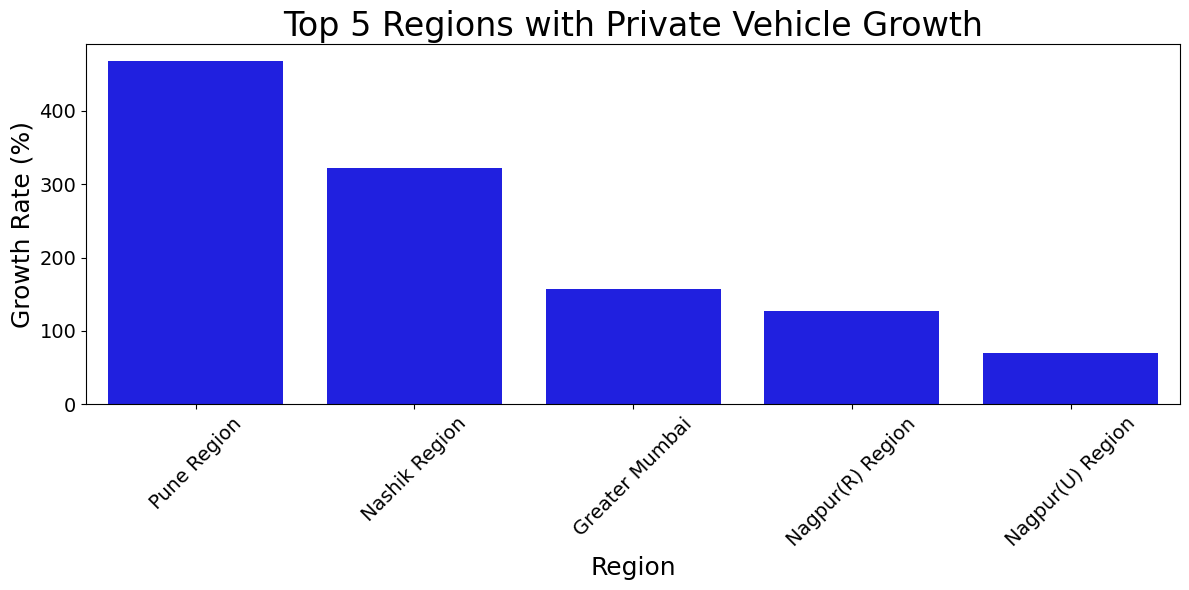

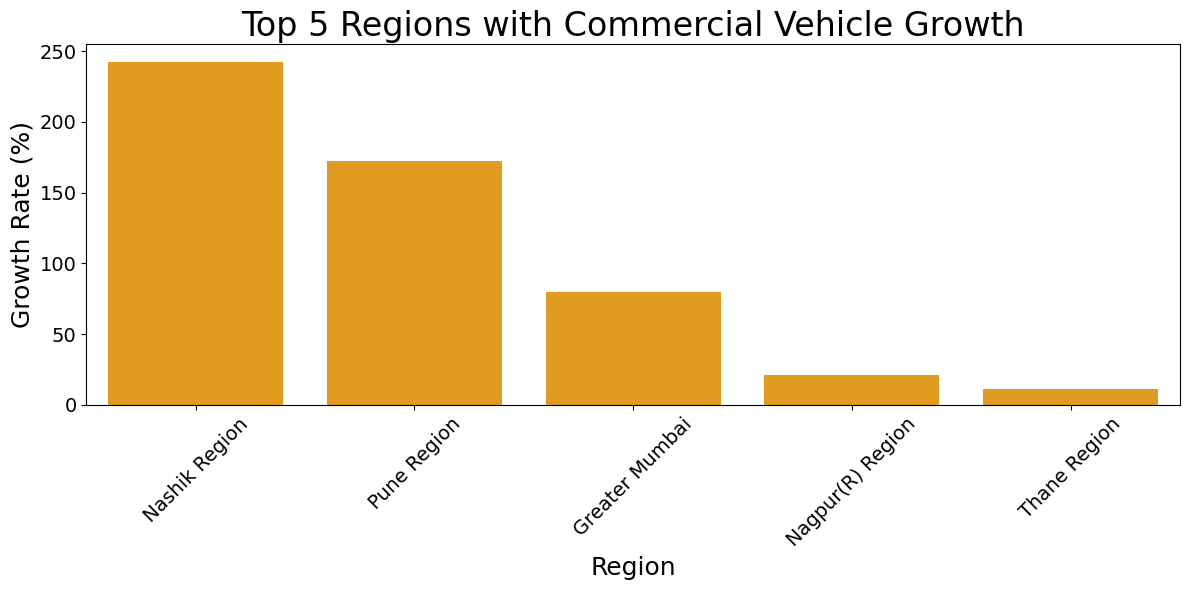

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the total vehicles by region
region_trends = df.groupby('Region').sum()[['Private Vehicles TOTAL', 'Commercial vehicles TOTAL']]

# Calculate growth rates (percentage change) for private and commercial vehicles
region_trends['Private Growth Rate (%)'] = region_trends['Private Vehicles TOTAL'].pct_change().fillna(0) * 100
region_trends['Commercial Growth Rate (%)'] = region_trends['Commercial vehicles TOTAL'].pct_change().fillna(0) * 100

# Replace "inf" or extreme growth rates with NaN to exclude them from the plot
region_trends.replace([np.inf, -np.inf], np.nan, inplace=True)
region_trends = region_trends[(region_trends['Private Growth Rate (%)'] < 500) &
                              (region_trends['Commercial Growth Rate (%)'] < 500)]

# Sort by growth rates and get the top 5 regions for each category
top_private_growth = region_trends.sort_values('Private Growth Rate (%)', ascending=False).head(5)
top_commercial_growth = region_trends.sort_values('Commercial Growth Rate (%)', ascending=False).head(5)

# Print the results
print("\nTop 5 Regions with Highest Private Vehicle Growth:")
print(top_private_growth[['Private Growth Rate (%)', 'Private Vehicles TOTAL']])

print("\nTop 5 Regions with Highest Commercial Vehicle Growth:")
print(top_commercial_growth[['Commercial Growth Rate (%)', 'Commercial vehicles TOTAL']])

# Visualize the private vehicle growth rates
plt.figure(figsize=(12, 6))
sns.barplot(data=top_private_growth, x=top_private_growth.index, y='Private Growth Rate (%)', color='blue')
plt.title('Top 5 Regions with Private Vehicle Growth')
plt.xlabel('Region')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize the commercial vehicle growth rates
plt.figure(figsize=(12, 6))
sns.barplot(data=top_commercial_growth, x=top_commercial_growth.index, y='Commercial Growth Rate (%)', color='orange')
plt.title('Top 5 Regions with Commercial Vehicle Growth')
plt.xlabel('Region')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [62]:
# Step 4: Policy Planning and Business Strategies
# Identify regions with disproportionate growth in commercial vehicles
df['Private to Commercial Ratio'] = df['Private Vehicles TOTAL'] / (df['Commercial vehicles TOTAL'] + 1)

high_ratio_regions = df.groupby('Region')['Private to Commercial Ratio'].mean().sort_values(ascending=False)
print("\nRegions with Highest Private-to-Commercial Vehicle Ratios (Infrastructure Needs):")
print(high_ratio_regions.head(5))




Regions with Highest Private-to-Commercial Vehicle Ratios (Infrastructure Needs):
Region
Nagpur(U) Region    8.652724
Nagpur(R) Region    7.246496
Pune Region         6.598328
Amrawati Region     5.402605
Greater Mumbai      5.316835
Name: Private to Commercial Ratio, dtype: float64


<ipython-input-63-176e03b4862c>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=region_trends.index, y=region_trends['Commercial vehicles TOTAL'], ci=None)


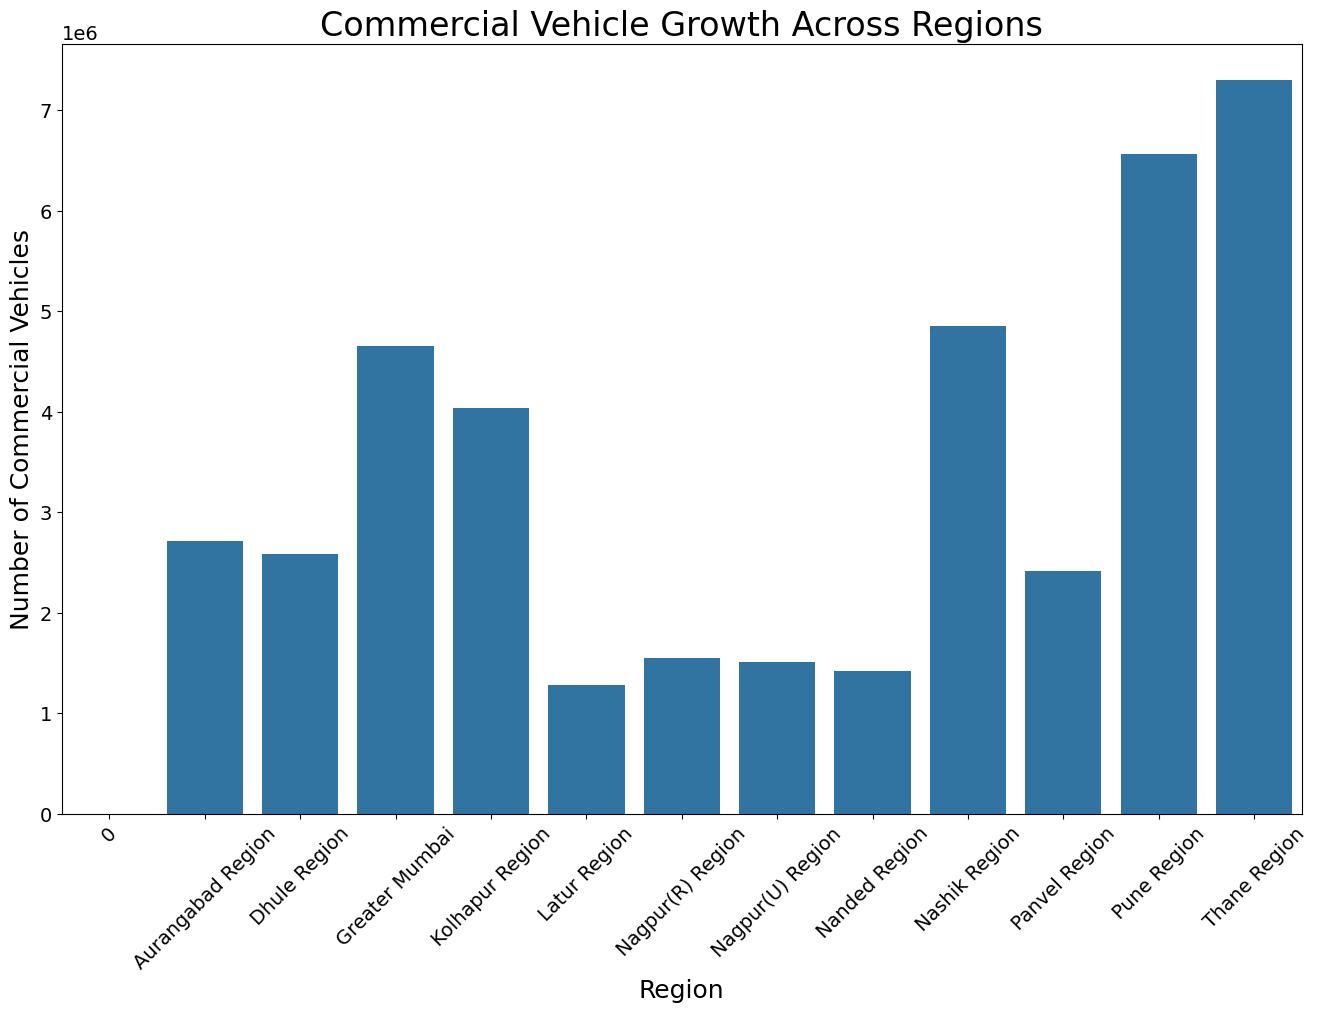

In [63]:
# Plot regions with high commercial vehicle growth
plt.figure()
sns.barplot(x=region_trends.index, y=region_trends['Commercial vehicles TOTAL'], ci=None)
plt.title('Commercial Vehicle Growth Across Regions')
plt.ylabel('Number of Commercial Vehicles')
plt.xticks(rotation=45)
plt.show()

In [64]:
# Step 5: Predict Future Trends (Forecasting Private Vehicle Population)
# Features for prediction
X = df[['Commercial vehicles TOTAL', 'Motor Cycles', 'Scooters', 'Moped', 'Cars']]  # Relevant features
y = df['Private Vehicles TOTAL']

# Ensure no missing values
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on Test Set
y_pred = model.predict(X_test)

# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance:\nMSE: {mse}\nR2 Score: {r2}")

# Predict future trends using dummy data
future_data = pd.DataFrame({
    'Commercial vehicles TOTAL': [90000, 100000],
    'Motor Cycles': [130000, 140000],
    'Scooters': [75000, 80000],
    'Moped': [30000, 35000],
    'Cars': [60000, 65000]
})
future_predictions = model.predict(future_data)
print("\nFuture Predictions for Private Vehicles TOTAL:")
print(future_predictions)


Model Performance:
MSE: 8563271.600185163
R2 Score: 0.9998988214583353

Future Predictions for Private Vehicles TOTAL:
[307957.53594746 334443.49361936]


<ipython-input-64-14cc836d0032>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(0, inplace=True)


Here are the insights derived from your model and predictions, explained in simple terms:

---

### **Model Performance**
- **Mean Squared Error (MSE)**: The MSE value of `8,563,271.60` is quite low, indicating that the difference between the actual and predicted values is minimal. This means the model is performing well in predicting the private vehicle totals.
- **R² Score**: The R² score of `0.9999` suggests that the model explains 99.99% of the variance in the data. In other words, the model is extremely accurate in capturing the relationship between the features (like commercial vehicles, motorcycles, scooters, etc.) and the total number of private vehicles.

---

### **Future Predictions for Private Vehicles**
- Based on the model, the total number of private vehicles is predicted to be approximately:
  - **307,957** for the first scenario (based on the provided future input data).
  - **334,443** for the second scenario.
- These predictions suggest that private vehicle ownership will continue to grow in the near future, assuming the trends in commercial vehicles, motorcycles, scooters, mopeds, and cars remain consistent.

---

### **Insights**
1. **Strong Model Accuracy**:
   - The high R² score indicates that the model is reliable for making predictions about private vehicle populations based on the given features.

2. **Future Growth in Private Vehicles**:
   - The predictions show a steady increase in the number of private vehicles, highlighting potential areas where infrastructure upgrades (e.g., parking spaces, road networks) might be necessary to support the growing demand.

3. **Strategic Focus on Related Factors**:
   - Since features like commercial vehicles, motorcycles, scooters, mopeds, and cars strongly influence private vehicle totals, policies targeting these areas (e.g., incentives for electric two-wheelers or shared mobility services) could significantly impact future private vehicle growth.

4. **Urban Congestion Concerns**:
   - If the growth in private vehicles continues at this rate, urban areas might face challenges like traffic congestion and pollution. Policymakers and businesses might consider promoting public transportation or environmentally friendly vehicles to mitigate these issues.

---

### **What This Means for Policymakers and Businesses**
- **Policymakers**:
  - Should prepare for increased vehicle usage by upgrading infrastructure (roads, parking, etc.).
  - Consider introducing eco-friendly policies to counter the environmental impact of rising vehicle numbers.
  
- **Businesses**:
  - Companies in the automotive and transport sectors could leverage this growth by expanding services and product offerings in high-demand regions.

---

Let me know if you'd like to refine these insights further!